In [13]:
# To calculate log-like we will use the original n(z), Cell's calculated using this n(z), and the covariance matrix #

# General imports #
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# Import euclidlib for reading the Euclid data #
import euclidlib as el

# Import cloelib for cosmology and theoretical predictions #
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint

# Import cloelike for likelihood computations #
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt




[-1.12705403 -0.98420551 -0.88449817 -0.7430882  -0.62523836 -0.49177027
 -0.35366025 -0.24620982 -0.06665165  0.12159365  0.3827588   0.8113496
  1.63762469]


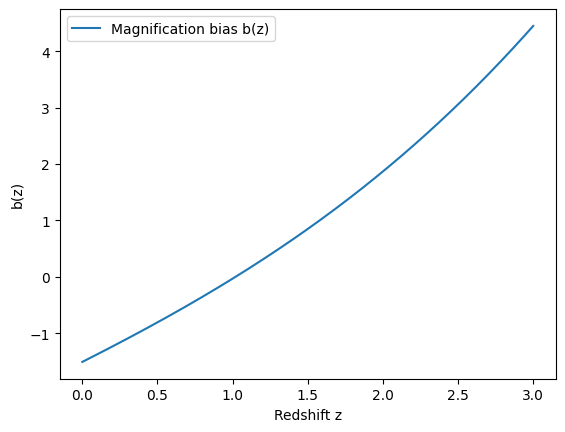

In [14]:
z_plot = np.linspace(0,3, 1000)
def b(z):
    b = -1.50685 + 1.35034*z + 0.08321*z**2 + 0.04279*z**3
    return b
b_mag = b(z_plot)
plt.plot(z_plot, b_mag, label='Magnification bias b(z)')
plt.xlabel('Redshift z')
plt.ylabel('b(z)')
plt.legend()

z_meds = []   # positions of median redshift for each bin
n_meds = []   # height of n(z) at median redshift for each bin

for key, nz in dndz_she_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z, initial=0)
    cdf /= cdf[-1]
    z_med = np.interp(0.5, cdf, z)
    n_med = nz[np.argmin(np.abs(z - z_med))]
    z_meds.append(z_med)
    n_meds.append(n_med)

b_values = b(np.array(z_meds))
print(b_values)

In [48]:
fiducial_cosmology = {'H0': 67.37, 
                        'Omega_cdm0': 0.27, 
                        'Omega_b0': 0.05, 
                        'w0': -1, 
                        'wa': 0, 
                        'Omega_k0': 0.0, 
                        'ns': 0.966, 
                        'As': 2.09e-9,
                        'mnu': 0.06,
                        'log10TAGN': 7.75,
                        'gamma_MG': 0.545,
                        'N_mnu': 1
                    }

fiducial_nuisance = {'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414,
                    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
                    'magnification_bias_1': b_values[0], 'magnification_bias_2': b_values[1],
                    'magnification_bias_3': b_values[2], 'magnification_bias_4': b_values[3],
                    'magnification_bias_5': b_values[4], 'magnification_bias_6': b_values[5],
                    'magnification_bias_7': b_values[6], 'magnification_bias_8': b_values[7],
                    'magnification_bias_9': b_values[8], 'magnification_bias_10': b_values[9],
                    'magnification_bias_11': b_values[10], 'magnification_bias_12': b_values[11],
                    'magnification_bias_13': b_values[12],
                    'dz_pos_1': -0.025749, 'dz_pos_2': 0.022716,
                    'dz_pos_3': -0.026032, 'dz_pos_4': 0.012594,
                    'dz_pos_5': 0.019285, 'dz_pos_6': 0.008326,
                    'dz_pos_7': 0.038207, 'dz_pos_8': 0.002732,
                    'dz_pos_9': 0.034066, 'dz_pos_10': 0.049479,
                    'dz_pos_11': 0.066490, 'dz_pos_12': 0.000815,
                    'dz_pos_13': 0.049070,
                    'AIA': 0.16, 'CIA': 0.0134, 'EtaIA':1.66,
                    'multiplicative_bias_1': 0.00, 'multiplicative_bias_2': 0.00,
                    'multiplicative_bias_3': 0.000, 'multiplicative_bias_4': 0.00,
                    'multiplicative_bias_5': 0.00, 'multiplicative_bias_6': 0.00,
                    'multiplicative_bias_7': 0.00, 'multiplicative_bias_8': 0.00,
                    'multiplicative_bias_9': 0.00, 'multiplicative_bias_10': 0.00,
                    'multiplicative_bias_11': 0.00, 'multiplicative_bias_12': 0.00,
                    'multiplicative_bias_13': 0.00,
                    'dz_shear_1': -0.025749, 'dz_shear_2': 0.022716,
                    'dz_shear_3': -0.026032, 'dz_shear_4': 0.012594,
                    'dz_shear_5': 0.019285, 'dz_shear_6': 0.008326,
                    'dz_shear_7': 0.038207, 'dz_shear_8': 0.002732,
                    'dz_shear_9': 0.034066, 'dz_shear_10': 0.049479,
                    'dz_shear_11': 0.066490, 'dz_shear_12': 0.000815,
                    'dz_shear_13': 0.049070}                    

In [22]:
# Import and prepare original n(z) distribution #

zs = np.linspace(1e-4, 3, 100)
z, nz = el.phz.redshift_distributions('/home/jipdebuck/nzTabSPV3.fits')

def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz, z)
dndz_she_norm = normalize_dndz(nz, z)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values())) #stacking arrays vertically
    my_dndz_norm = np.zeros([len(nz_example), len(myz)]) #creating an empty array
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :]) #interpolating to new myz values
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z, zs)

In [23]:
# Compute the C_ell's using the original n(z) and fiducial values from overview paper #

# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=fiducial_cosmology['H0'], 
                            Omega_cdm0=fiducial_cosmology['Omega_cdm0'], 
                            Omega_b0=fiducial_cosmology['Omega_b0'], 
                            w0=fiducial_cosmology['w0'], 
                            wa=fiducial_cosmology['wa'], 
                            Omega_k0 = fiducial_cosmology['Omega_k0'], 
                            ns = fiducial_cosmology['ns'], 
                            As = fiducial_cosmology['As'],
                            mnu = fiducial_cosmology['mnu'],
                            gamma_MG = fiducial_cosmology['gamma_MG'],
                            N_mnu = fiducial_cosmology['N_mnu'])
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, zs, log10TAGN=fiducial_cosmology['log10TAGN'])

# Select the perturbations object you want to use
perturbations = nonlinear_perturbations_emu

# Define the tracers
tracer_pos = PositionsTracer(perturbations=perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = zs,
                             galaxy_bias_model='poly',
                             nuisance_params={'b1_photo_poly0': fiducial_nuisance['b1_photo_poly0'], 'b1_photo_poly1': fiducial_nuisance['b1_photo_poly1'],
                                              'b1_photo_poly2': fiducial_nuisance['b1_photo_poly2'], 'b1_photo_poly3': fiducial_nuisance['b1_photo_poly3'],
                                              'magnification_bias_1': fiducial_nuisance['magnification_bias_1'], 'magnification_bias_2': fiducial_nuisance['magnification_bias_2'],
                                              'magnification_bias_3': fiducial_nuisance['magnification_bias_3'], 'magnification_bias_4': fiducial_nuisance['magnification_bias_4'],
                                              'magnification_bias_5': fiducial_nuisance['magnification_bias_5'], 'magnification_bias_6': fiducial_nuisance['magnification_bias_6'],
                                              'magnification_bias_7': fiducial_nuisance['magnification_bias_7'], 'magnification_bias_8': fiducial_nuisance['magnification_bias_8'],
                                              'magnification_bias_9': fiducial_nuisance['magnification_bias_9'], 'magnification_bias_10': fiducial_nuisance['magnification_bias_10'],
                                              'magnification_bias_11': fiducial_nuisance['magnification_bias_11'], 'magnification_bias_12': fiducial_nuisance['magnification_bias_12'],
                                              'magnification_bias_13': fiducial_nuisance['magnification_bias_13'],
                                              'dz_pos_1': fiducial_nuisance['dz_pos_1'], 'dz_pos_2': fiducial_nuisance['dz_pos_2'],
                                              'dz_pos_3': fiducial_nuisance['dz_pos_3'], 'dz_pos_4': fiducial_nuisance['dz_pos_4'],
                                              'dz_pos_5': fiducial_nuisance['dz_pos_5'], 'dz_pos_6': fiducial_nuisance['dz_pos_6'],
                                              'dz_pos_7': fiducial_nuisance['dz_pos_7'], 'dz_pos_8': fiducial_nuisance['dz_pos_8'],
                                              'dz_pos_9': fiducial_nuisance['dz_pos_9'], 'dz_pos_10': fiducial_nuisance['dz_pos_10'],
                                              'dz_pos_11': fiducial_nuisance['dz_pos_11'], 'dz_pos_12': fiducial_nuisance['dz_pos_12'],
                                              'dz_pos_13': fiducial_nuisance['dz_pos_13']})

tracer_she = ShearTracer(perturbations=perturbations, 
                             dndz=my_dndz_she_norm,
                             z = zs,
                             nuisance_params={'AIA': fiducial_nuisance['AIA'], 'CIA': fiducial_nuisance['CIA'], 'EtaIA':fiducial_nuisance['EtaIA'],
                                              'multiplicative_bias_1': fiducial_nuisance['multiplicative_bias_1'], 'multiplicative_bias_2': fiducial_nuisance['multiplicative_bias_2'],
                                              'multiplicative_bias_3': fiducial_nuisance['multiplicative_bias_3'], 'multiplicative_bias_4': fiducial_nuisance['multiplicative_bias_4'],
                                              'multiplicative_bias_5': fiducial_nuisance['multiplicative_bias_5'], 'multiplicative_bias_6': fiducial_nuisance['multiplicative_bias_6'],
                                              'multiplicative_bias_7': fiducial_nuisance['multiplicative_bias_7'], 'multiplicative_bias_8': fiducial_nuisance['multiplicative_bias_8'],
                                              'multiplicative_bias_9': fiducial_nuisance['multiplicative_bias_9'], 'multiplicative_bias_10': fiducial_nuisance['multiplicative_bias_10'],
                                              'multiplicative_bias_11': fiducial_nuisance['multiplicative_bias_11'], 'multiplicative_bias_12': fiducial_nuisance['multiplicative_bias_12'],
                                              'multiplicative_bias_13': fiducial_nuisance['multiplicative_bias_13'],
                                              'dz_shear_1': fiducial_nuisance['dz_shear_1'], 'dz_shear_2': fiducial_nuisance['dz_shear_2'],
                                              'dz_shear_3': fiducial_nuisance['dz_shear_3'], 'dz_shear_4': fiducial_nuisance['dz_shear_4'],
                                              'dz_shear_5': fiducial_nuisance['dz_shear_5'], 'dz_shear_6': fiducial_nuisance['dz_shear_6'],
                                              'dz_shear_7': fiducial_nuisance['dz_shear_7'], 'dz_shear_8': fiducial_nuisance['dz_shear_8'],
                                              'dz_shear_9': fiducial_nuisance['dz_shear_9'], 'dz_shear_10': fiducial_nuisance['dz_shear_10'],
                                              'dz_shear_11': fiducial_nuisance['dz_shear_11'], 'dz_shear_12': fiducial_nuisance['dz_shear_12'],
                                              'dz_shear_13': fiducial_nuisance['dz_shear_13']})

In [24]:
# Compute angular two-point statistics #

nl = 32
ells = np.array([
    11.07173512, 13.44492858, 16.32680901, 19.82641192,
    24.07614430, 29.23679417, 35.50361397, 43.11370795,
    52.35500292, 63.57714196, 77.20471310, 93.75331355,
    113.84905725, 138.25226380, 167.88622503, 203.87213764,
    247.57152351, 300.63774267, 365.07854795, 443.33204803,
    538.35895294, 653.75459205, 793.88494293, 964.05181742,
    1170.69345495, 1421.62811240, 1726.34986676, 2096.38782216,
    2545.74231185, 3091.41459890, 3754.05011646, 4558.71958485
])

twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
twopoint_posshe = AngularTwoPoint(tracer_pos, tracer_she)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)

In [25]:
covmat_3x2pt = np.load("/home/jipdebuck/CovMat-3x2pt-GaussSSC-32Bins-13245deg2.npy")
mixmats = el.le3.pk_wl.mixing_matrices('/home/jipdebuck/files/mixmats_example.fits')
cls_data ={**twopoint_sheshe.get_Cl(ells, 0, perturbations.k)
, **twopoint_posshe.get_Cl(ells, 0, perturbations.k)
, **twopoint_pospos.get_Cl(ells, 0, perturbations.k)}

In [26]:
el.le3.pk_wl.angular_power_spectra.write('fiducial_cls_3x2pt_DR3.fits', cls_data)

In [27]:
def build_data(ell_key, cov, include_pos=False, include_she=False):
    data = {
        'cells': cls_data,
        'ells': cls_data[ell_key].ell,
        'z_arr': zs,
        'cov': cov,
        'mixmat': mixmats,
    }
    if include_pos:
        data['dndz_pos'] = my_dndz_pos_norm
    if include_she:
        data['dndz_she'] = my_dndz_she_norm
    return data

def build_settings():
    scale_cuts = {key: [5, 3000] for key in cls_data}
    return {'n_ell_bins': 32, 'scale_cuts': scale_cuts}

# Build each dataset with correct dndz components
data_3x2pt  = build_data(('POS', 'POS', 1, 1), covmat_3x2pt, include_pos=True, include_she=True)

# Settings (same for all, built from cells_data structure)
settings_3x2pt  = build_settings()

In [28]:
import time

likelihood_classes = {
    '3x2pt': EuclidLikelihood_3x2pt,
}

data_dicts = {
    '3x2pt': (data_3x2pt, settings_3x2pt),
}

like_tests = {}
loglike_results = {}

print("🔍 Timing log-likelihood initialisation (this only happens once) and displaying results:")

for label in ['3x2pt']:
    print(f"\n📊 {label} loglike:")
    data, settings = data_dicts[label]
    cls = likelihood_classes[label]

    start = time.time()
    like_tests[label] = cls(
        data=data,
        settings=settings,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
        mode = 'uncoupled'
    )
    end = time.time()
    print(f"⏱️ Time elapsed ({label}): {end - start:.3f} seconds")

🔍 Timing log-likelihood initialisation (this only happens once) and displaying results:

📊 3x2pt loglike:
⏱️ Time elapsed (3x2pt): 0.441 seconds


In [39]:
# Dictionary of pretty names for output
labels_pretty = {
    '3x2pt': "3x2pt"
}

print("⏱️ Timing log-likelihood evaluations and displaying results:")

loglike_results = {}

for label in ['3x2pt']:
    print(f"\n📊 {labels_pretty[label]} loglike:")
    start = time.time()
    result = like_tests[label].loglike(fiducial_cosmology | fiducial_nuisance)
    elapsed = time.time() - start
    loglike_results[label] = result
    print(f"✅ Returned value ({label}): {result}")
    print(f"⏱️ Time elapsed ({label}): {elapsed:.3f} seconds")


⏱️ Timing log-likelihood evaluations and displaying results:

📊 3x2pt loglike:
✅ Returned value (3x2pt): 0.0
⏱️ Time elapsed (3x2pt): 1.603 seconds



🔄 Scanning over $\Omega_{cdm} h^2$ for 3x2pt


3x2pt: 100%|████████████████████████████████████| 50/50 [00:54<00:00,  1.09s/it]


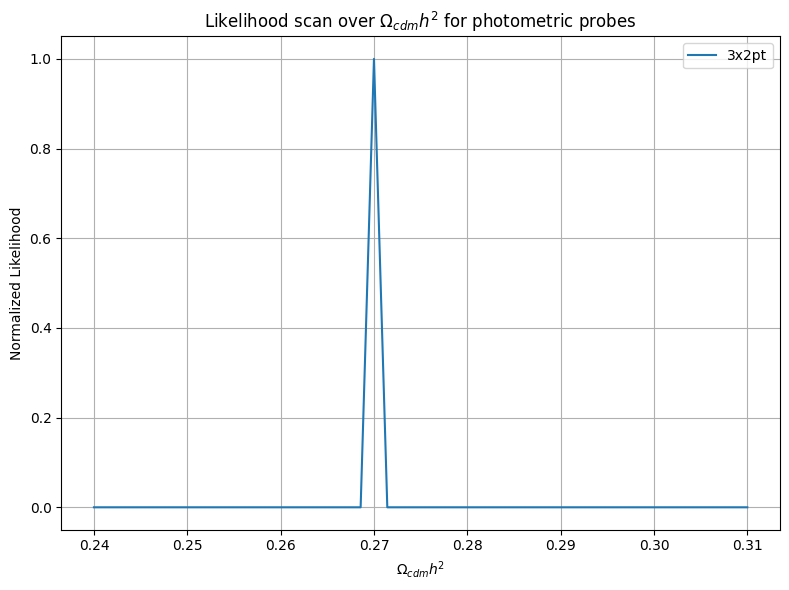

In [40]:
from tqdm import tqdm

# Define the range of Omega_cdm0 values to scan
oms = np.linspace(0.24, 0.31, 50)

# Prepare the figure
plt.figure(figsize=(8,6))

for label in ['3x2pt']:
    print(f"\n🔄 Scanning over $\Omega_{{cdm}} h^2$ for {label}")
    likelihood_curve = []

    for om in tqdm(oms, desc=f"{label}", ncols=80):
        # Update Omega_cdm0 parameter from omch2 and H0
        fiducial_cosmology['Omega_cdm0'] = om 

        # Compute log-likelihood
        ll = like_tests[label].loglike(fiducial_cosmology | fiducial_nuisance)
        likelihood_curve.append(ll)
    
    # Convert log-likelihoods to likelihoods (exp) and normalize
    likelihood_curve = np.exp(likelihood_curve - np.max(likelihood_curve))
    
    # Plot
    plt.plot(oms, likelihood_curve, label=label)

plt.xlabel(r'$\Omega_{cdm} h^2$')
plt.ylabel('Normalized Likelihood')
plt.title('Likelihood scan over $\Omega_{cdm} h^2$ for photometric probes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



🔄 Scanning over Omega_cdm0 for 3x2pt


3x2pt: 100%|████████████████████████████████████| 50/50 [01:29<00:00,  1.79s/it]



🔄 Scanning over H0 for 3x2pt


3x2pt: 100%|████████████████████████████████████| 50/50 [01:40<00:00,  2.01s/it]



🔄 Scanning over Omega_b0 for 3x2pt


...

3x2pt: 100%|████████████████████████████████████| 50/50 [01:35<00:00,  1.92s/it]



🔄 Scanning over mnu for 3x2pt


3x2pt: 100%|████████████████████████████████████| 50/50 [01:06<00:00,  1.33s/it]



🔄 Scanning over gamma_MG for 3x2pt


3x2pt: 100%|████████████████████████████████████| 50/50 [01:05<00:00,  1.30s/it]


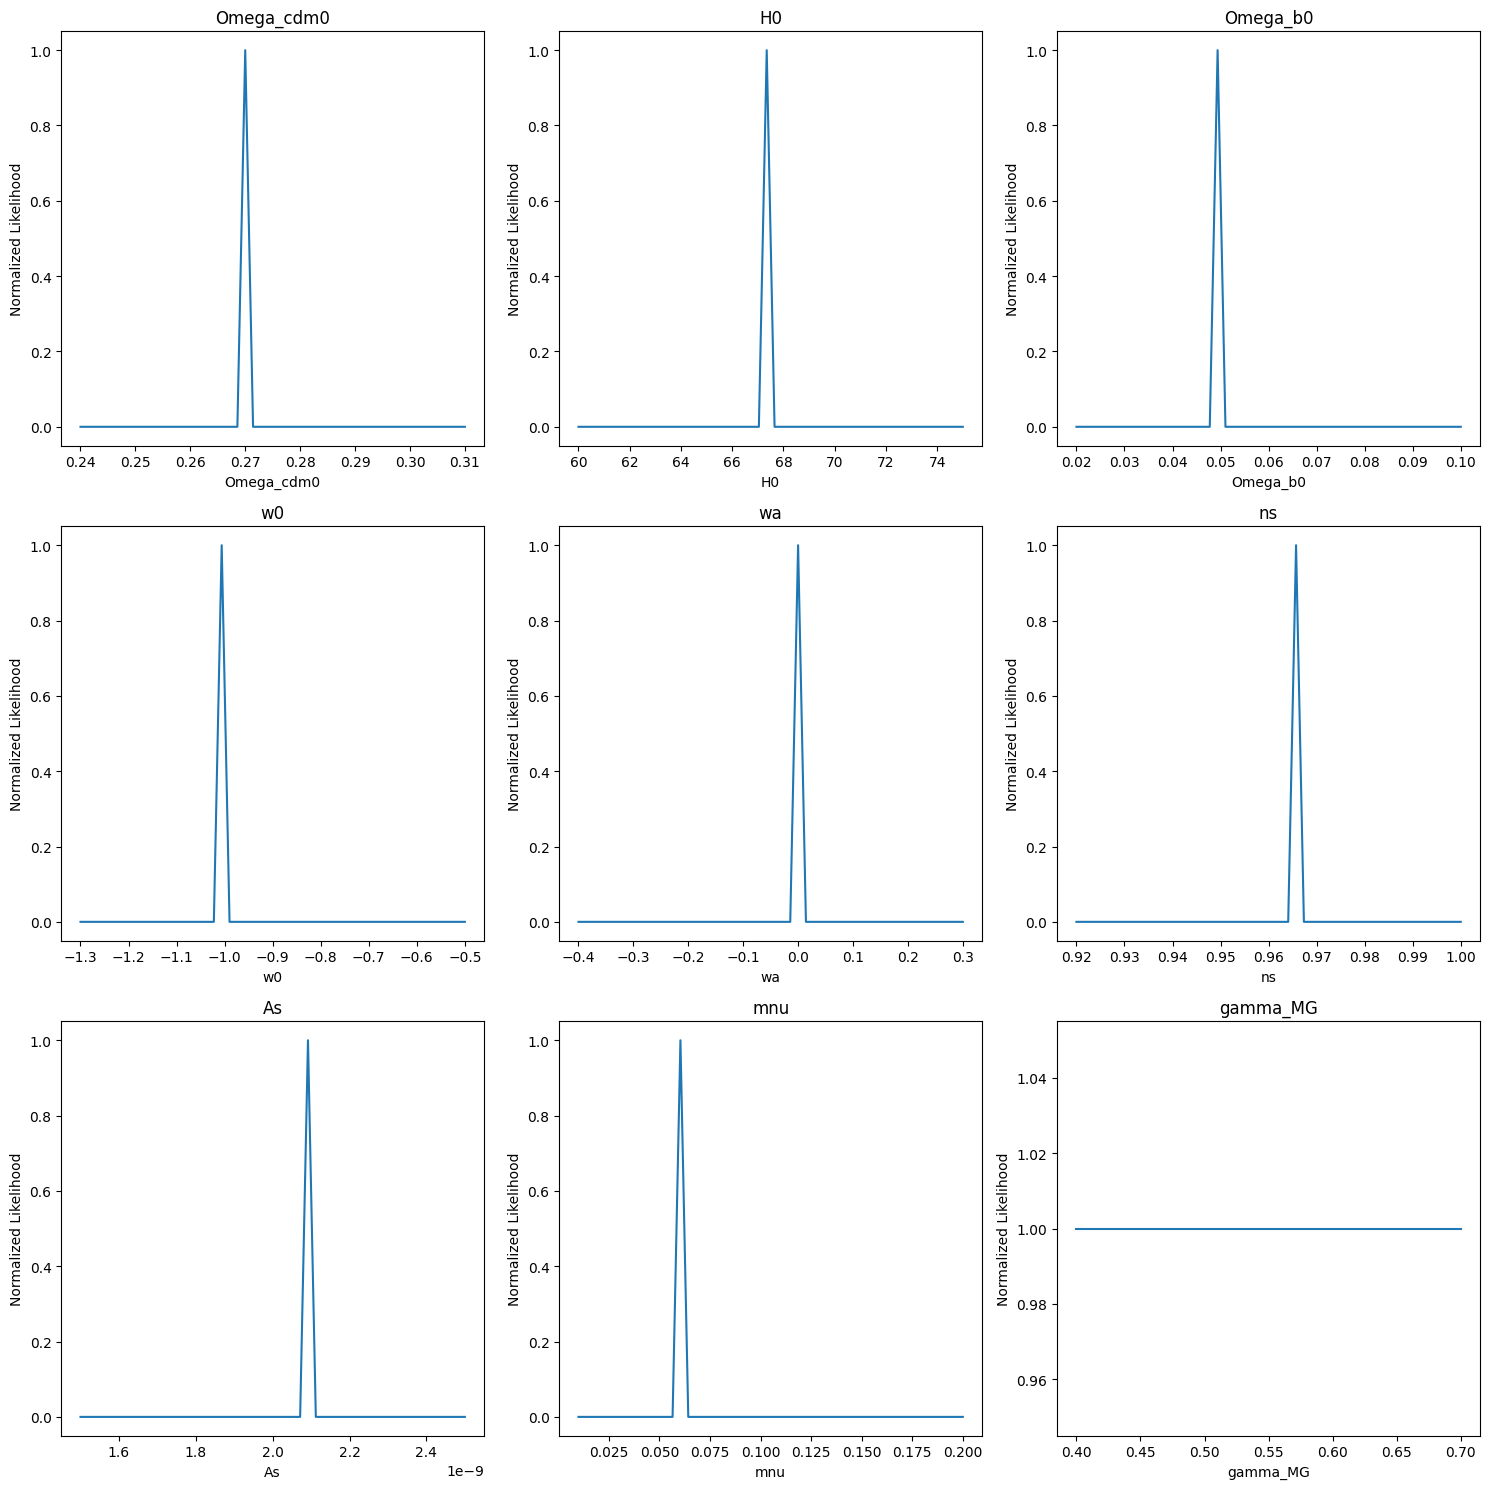

In [49]:
fig, axes = plt.subplots(3,3, figsize=(15,15))
axes = axes.flatten()
oms = np.linspace(0.24, 0.31, 50)
H0s = np.linspace(60, 75, 50)
om_b0s = np.linspace(0.02, 0.1, 50)
w0s = np.linspace(-1.3, -0.5, 50)
was = np.linspace(-0.4, 0.3, 50)
ns_s = np.linspace(0.92, 1.0, 50)
As_s = np.linspace(1.5e-9, 2.5e-9, 50)
mnus = np.linspace(0.01, 0.2, 50)
#log10TAGNs = np.linspace(7.0, 8.5, 50)
gamma_MGs = np.linspace(0.4, 0.7, 50)

params = {'Omega_cdm0': oms, 'H0': H0s, 'Omega_b0': om_b0s, 'w0': w0s, 'wa': was, 'ns': ns_s, 'As': As_s, 'mnu': mnus, 'gamma_MG': gamma_MGs}
keys = ['Omega_cdm0', 'H0', 'Omega_b0', 'w0', 'wa', 'ns', 'As', 'mnu', 'gamma_MG']
for label in ['3x2pt']:
#    print(f"\n🔄 Scanning over $\Omega_{{cdm}} h^2$ for {label}")

    for key, ax in zip(keys, axes):
        print(f"\n🔄 Scanning over {key} for {label}")
        likelihood_curve = []

        for value in tqdm(params[key], desc=f"{label}", ncols=80):
            # Update Omega_cdm0 parameter from omch2 and H0
            fid_cosm = fiducial_cosmology.copy()
            fid_cosm[key] = value

            # Compute log-likelihood
            ll = like_tests[label].loglike(fid_cosm | fiducial_nuisance)
            likelihood_curve.append(ll)
    
    # Convert log-likelihoods to likelihoods (exp) and normalize
        likelihood_curve = np.exp(likelihood_curve - np.max(likelihood_curve))
    
    # Plot
        ax.plot(params[key], likelihood_curve, label=label)
        ax.set_title(key)
        ax.set_xlabel(key)
        ax.set_ylabel('Normalized Likelihood')
plt.tight_layout()
plt.show()


🔄 Scanning over dz_pos_1 for 3x2pt


3x2pt: 100%|████████████████████████████████████| 50/50 [01:15<00:00,  1.51s/it]



🔄 Scanning over dz_pos_2 for 3x2pt


3x2pt: 100%|████████████████████████████████████| 50/50 [00:43<00:00,  1.16it/s]



🔄 Scanning over dz_pos_3 for 3x2pt


...

3x2pt: 100%|████████████████████████████████████| 50/50 [00:59<00:00,  1.20s/it]



🔄 Scanning over CIA for 3x2pt


3x2pt: 100%|████████████████████████████████████| 50/50 [00:44<00:00,  1.13it/s]



🔄 Scanning over EtaIA for 3x2pt


3x2pt: 100%|████████████████████████████████████| 50/50 [00:43<00:00,  1.16it/s]


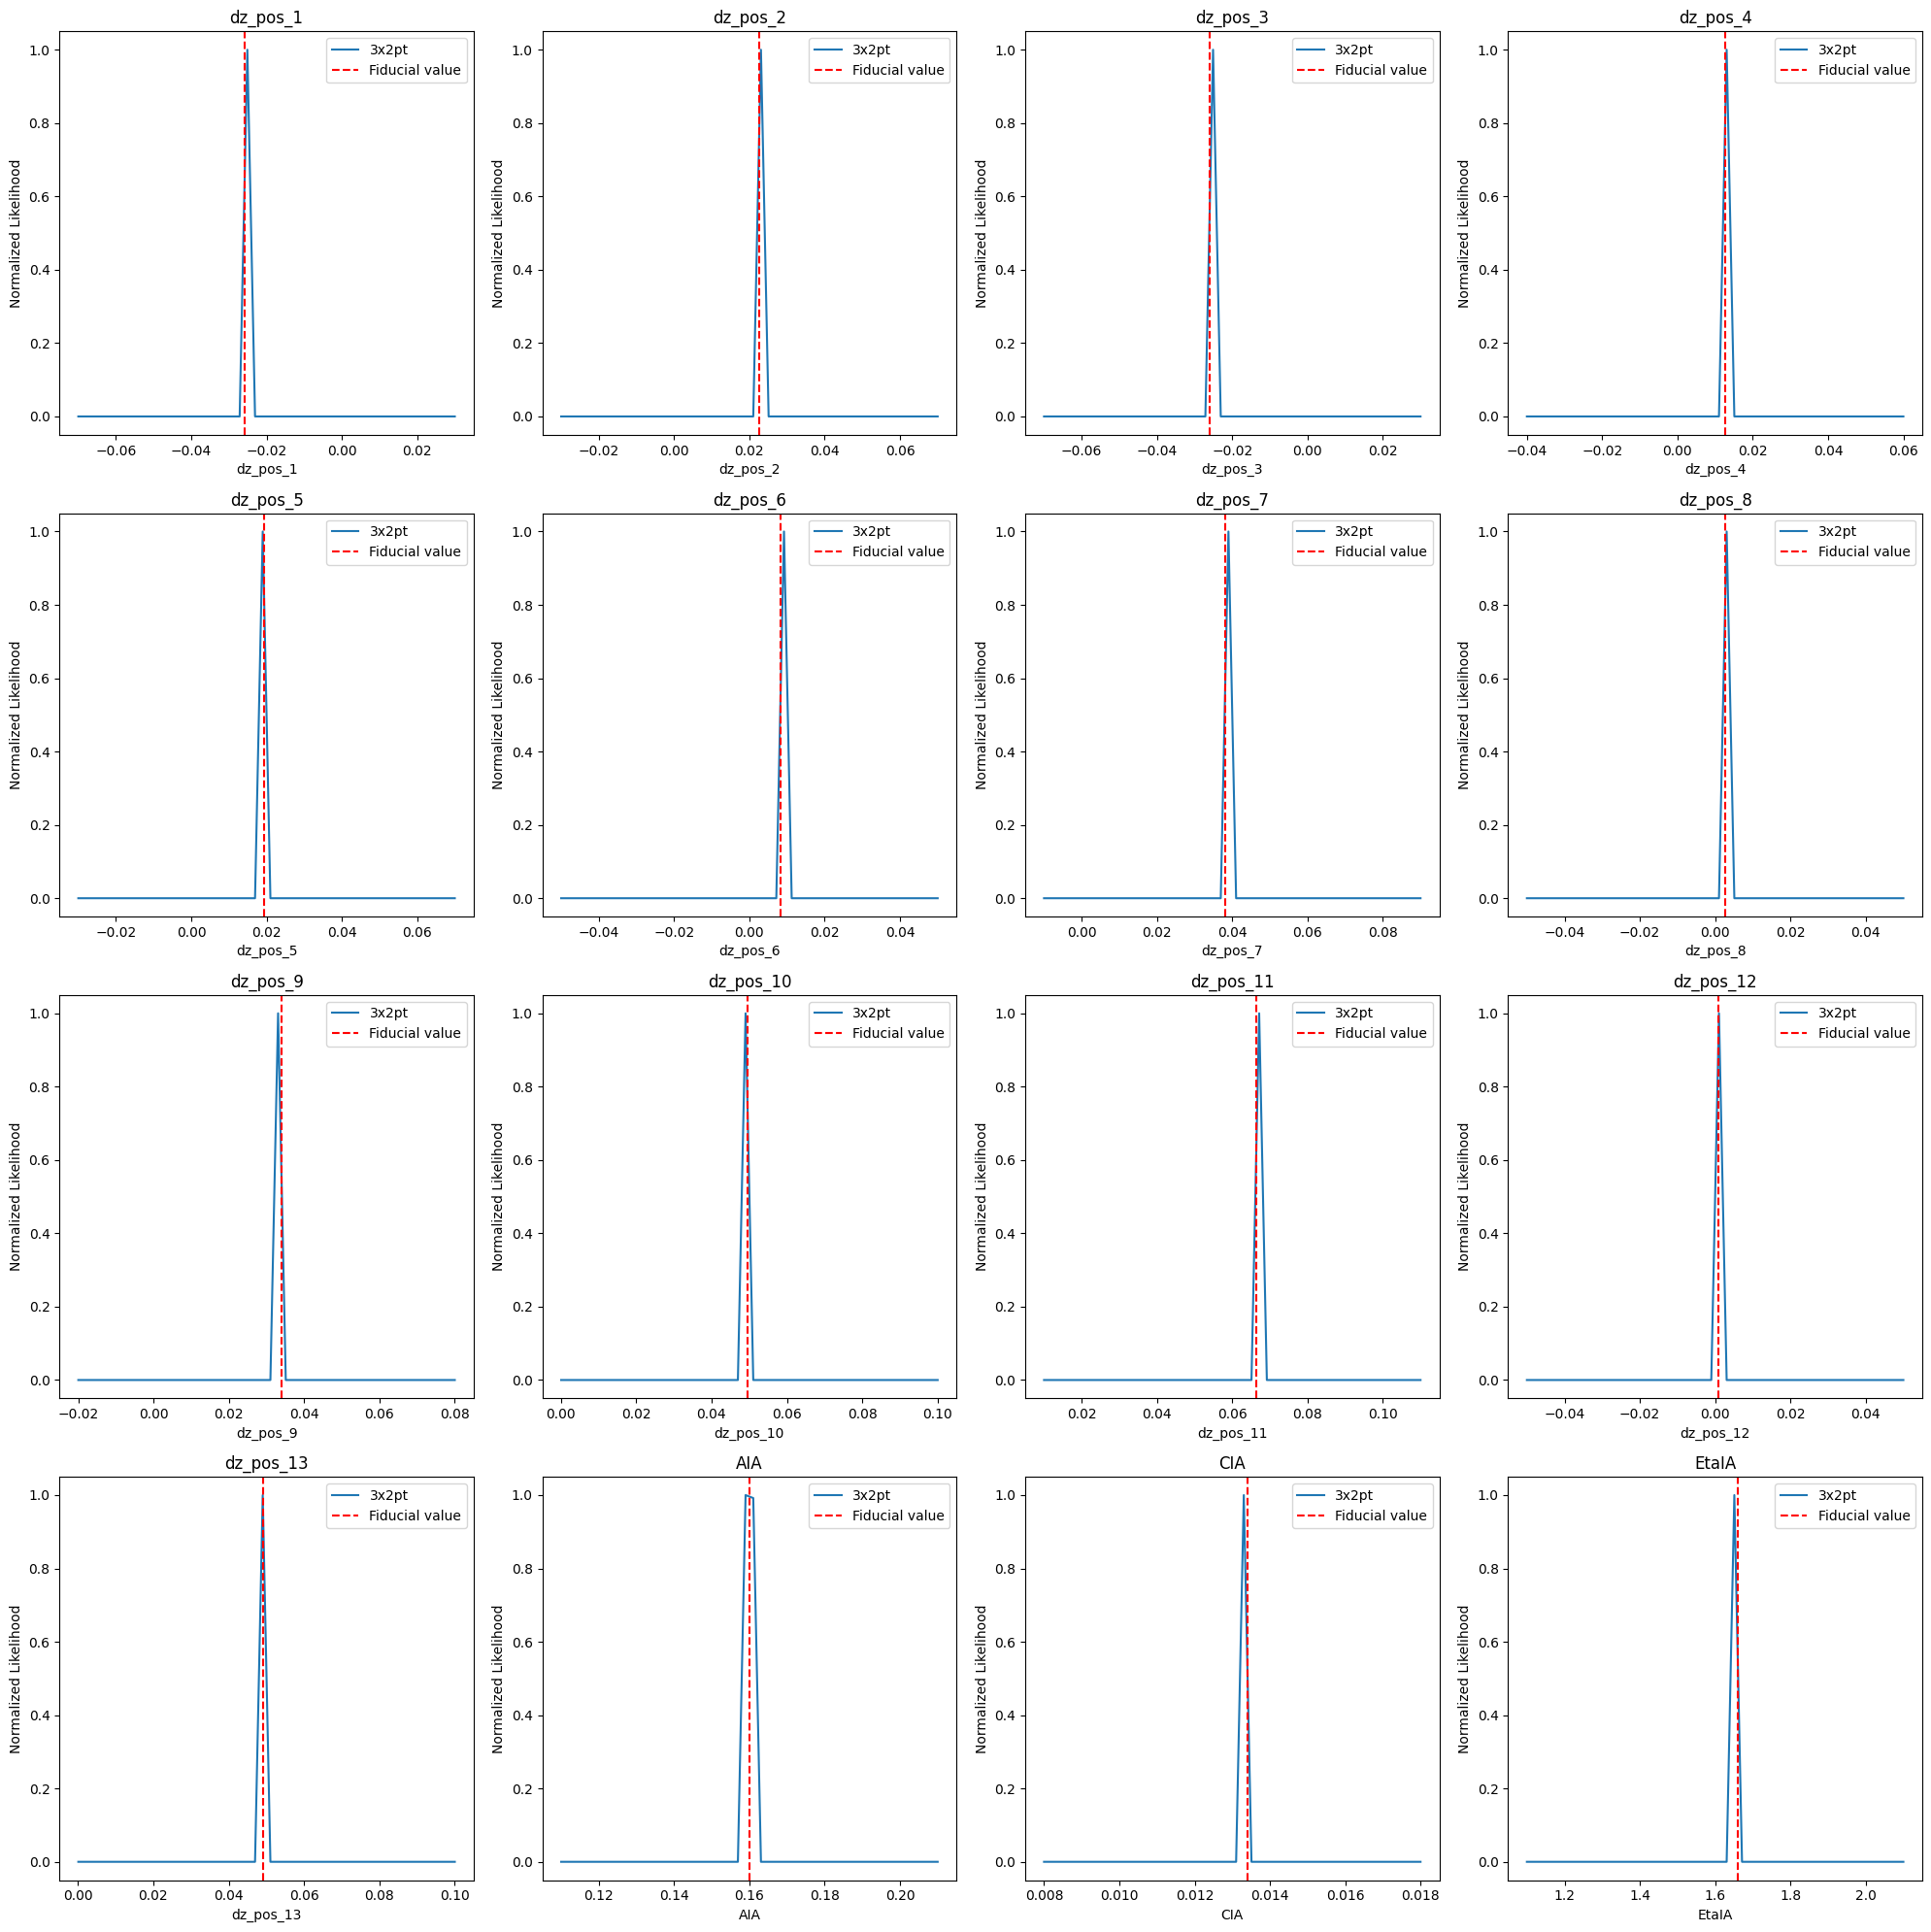

In [56]:
fig, axes = plt.subplots(4,4, figsize=(20,20))
axes = axes.flatten()

params_nuis = {'dz_pos_1': np.linspace(-0.07, 0.03, 50), 'dz_pos_2': np.linspace(-0.03, 0.07, 50),
                    'dz_pos_3': np.linspace(-0.07, 0.03, 50), 'dz_pos_4': np.linspace(-0.04, 0.06, 50),
                    'dz_pos_5': np.linspace(-0.03, 0.07, 50), 'dz_pos_6': np.linspace(-0.05, 0.05, 50),
                    'dz_pos_7': np.linspace(-0.01, 0.09, 50), 'dz_pos_8': np.linspace(-0.05, 0.05, 50),
                    'dz_pos_9': np.linspace(-0.02, 0.08, 50), 'dz_pos_10': np.linspace(0.0001, 0.1, 50),
                    'dz_pos_11': np.linspace(0.01, 0.11, 50), 'dz_pos_12': np.linspace(-0.05, 0.05, 50),
                    'dz_pos_13': np.linspace(0.0001, 0.1, 50),
                    'AIA': np.linspace(0.11, 0.21, 50), 'CIA': np.linspace(0.008, 0.018, 50), 'EtaIA':np.linspace(1.1, 2.1, 50)}
keys_nuis = ['dz_pos_1', 'dz_pos_2', 'dz_pos_3', 'dz_pos_4', 'dz_pos_5', 'dz_pos_6', 'dz_pos_7', 'dz_pos_8', 'dz_pos_9', 'dz_pos_10', 
             'dz_pos_11', 'dz_pos_12', 'dz_pos_13', 'AIA', 'CIA', 'EtaIA']

for label in ['3x2pt']:
#    print(f"\n🔄 Scanning over $\Omega_{{cdm}} h^2$ for {label}")
    likelihood_curves = {}
    for key, ax in zip(keys_nuis, axes):
        print(f"\n🔄 Scanning over {key} for {label}")
        likelihood_curve = []

        for value in tqdm(params_nuis[key], desc=f"{label}", ncols=80):
            # Update Omega_cdm0 parameter from omch2 and H0
            fid_nuis = fiducial_nuisance.copy()
            fid_nuis[key] = value

            # Compute log-likelihood
            ll = like_tests[label].loglike(fiducial_cosmology | fid_nuis)
            likelihood_curve.append(ll)
            likelihood_curves[key] = likelihood_curve
    
    # Convert log-likelihoods to likelihoods (exp) and normalize
        likelihood_curve = np.exp(likelihood_curve - np.max(likelihood_curve))
    
    # Plot
        ax.plot(params_nuis[key], likelihood_curve, label=label)
        ax.axvline(fiducial_nuisance[key], color='red', linestyle='--', label='Fiducial value')
        ax.set_title(key)
        ax.set_xlabel(key)
        ax.set_ylabel('Normalized Likelihood')
        ax.legend()
plt.tight_layout()
plt.show()

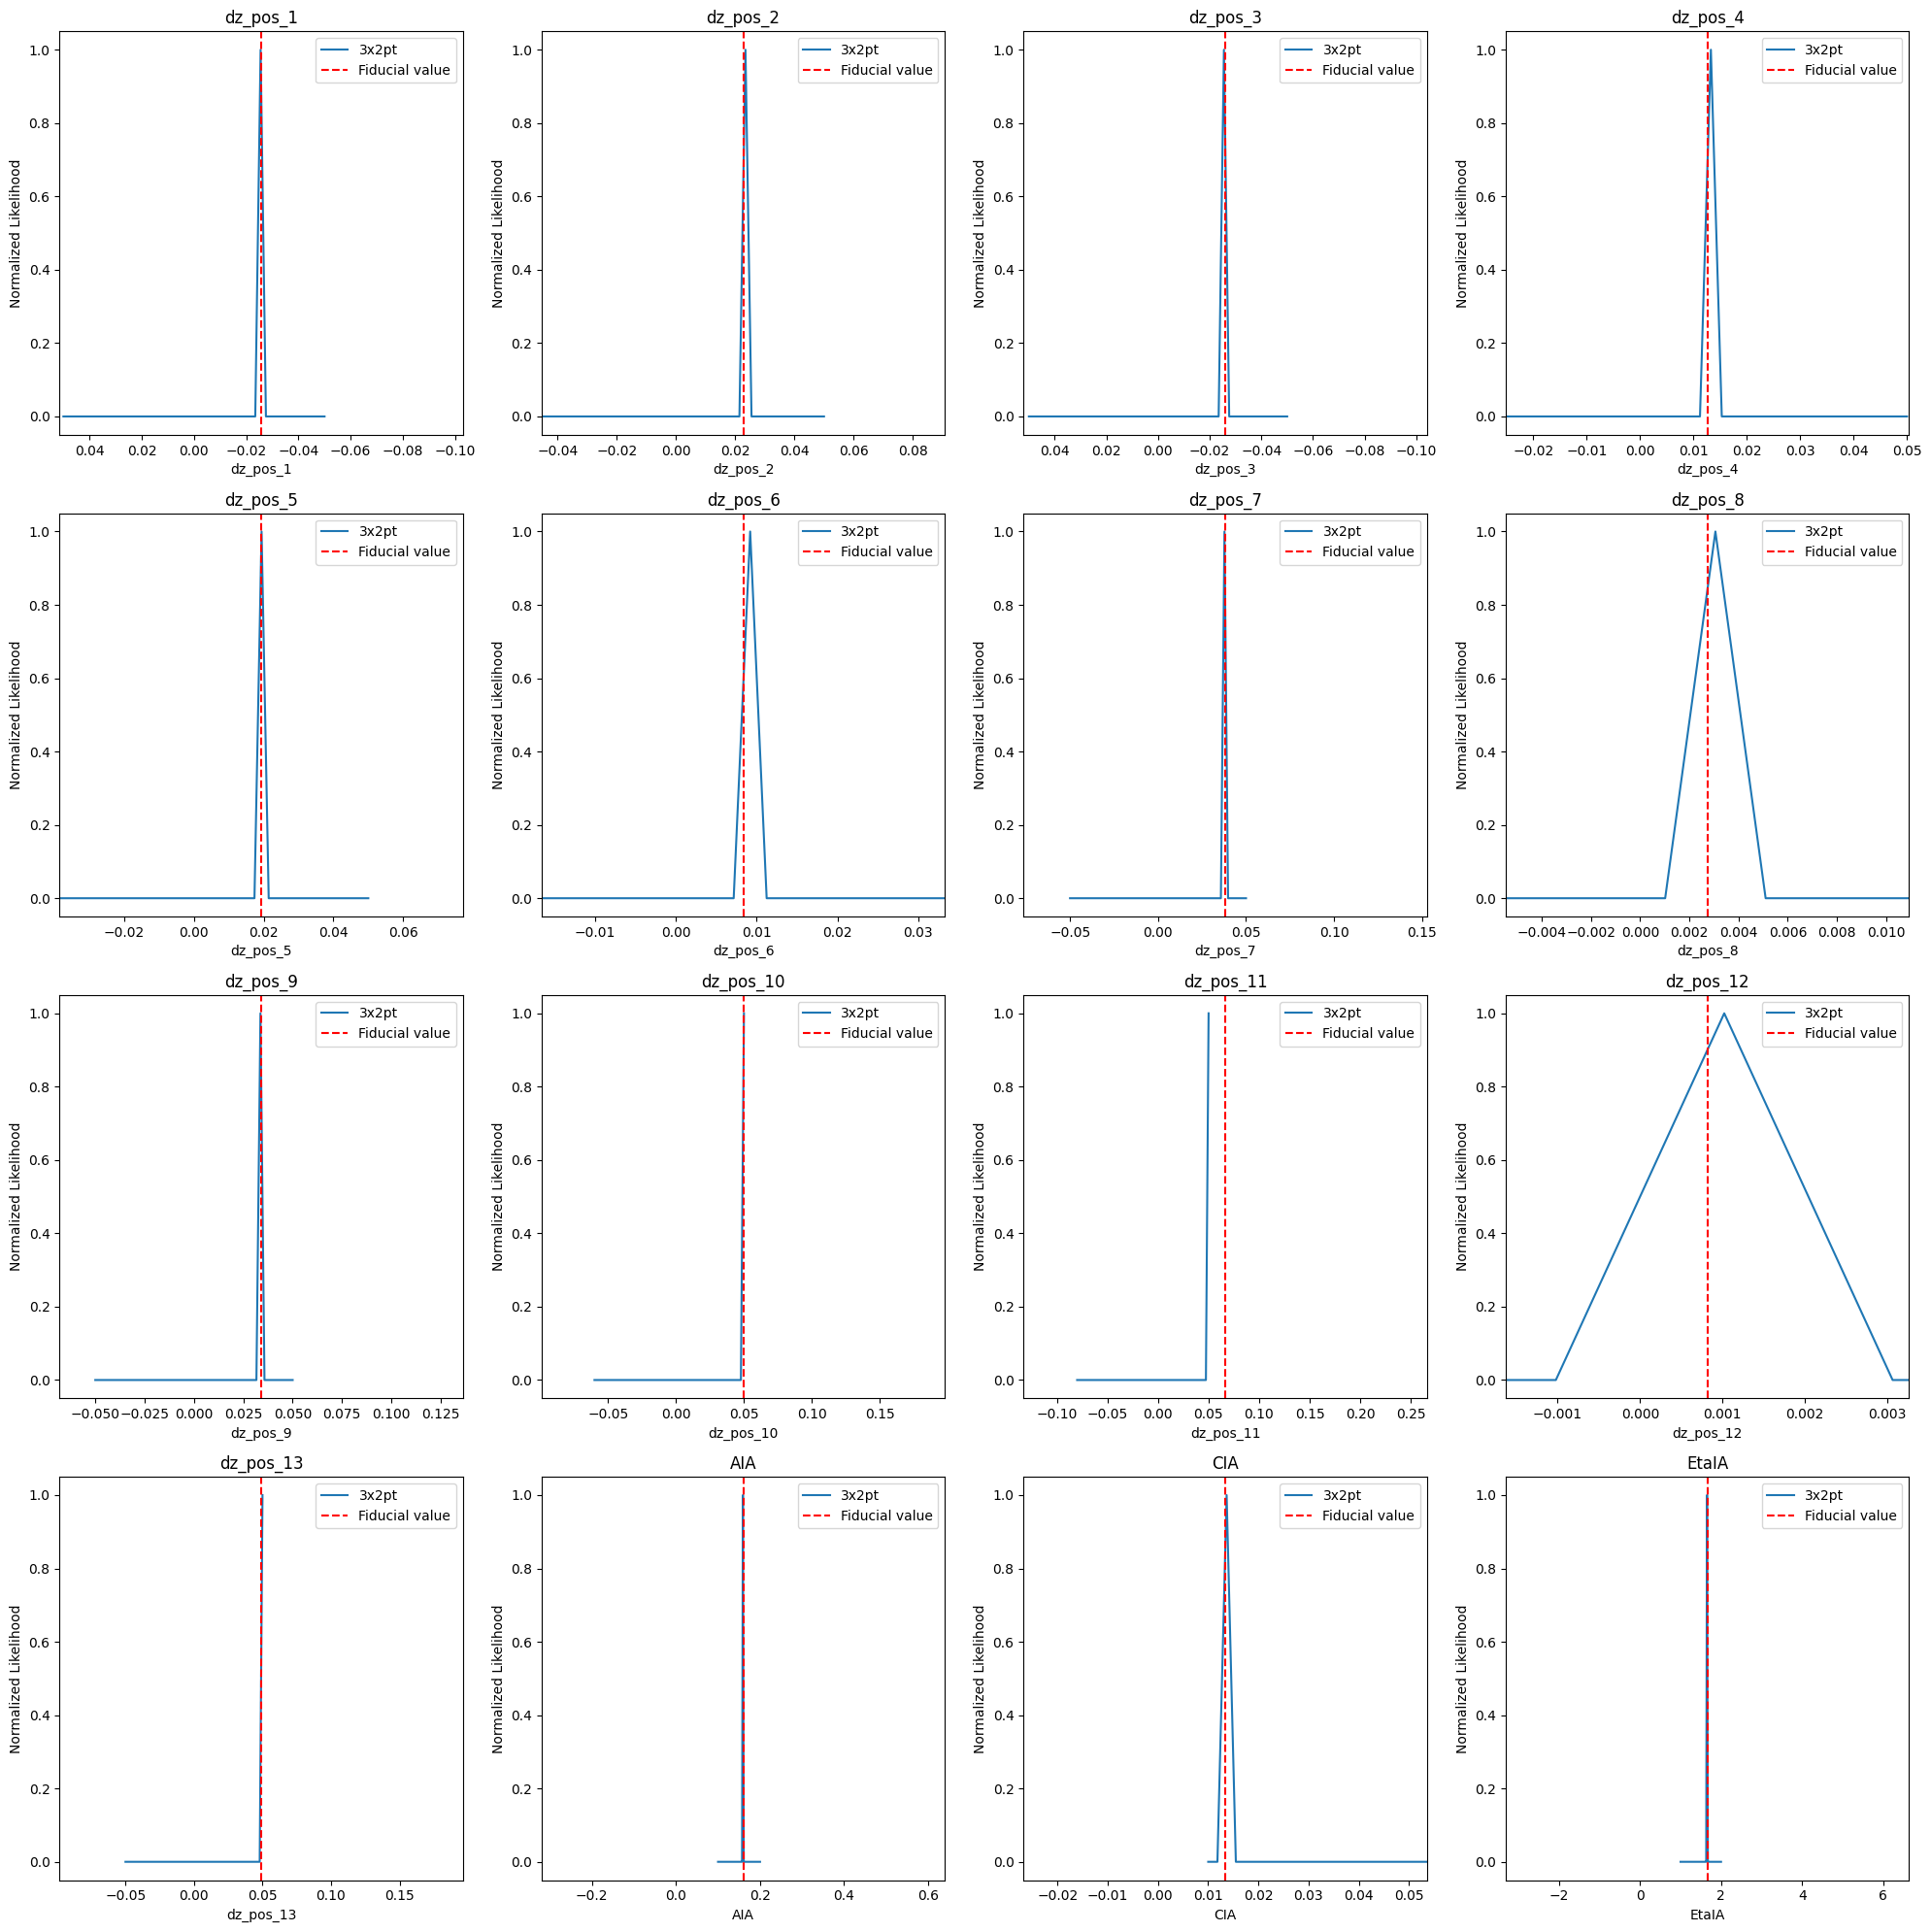

In [55]:
fig, axes = plt.subplots(4,4, figsize=(20,20))
axes = axes.flatten()


for key, ax in zip(keys_nuis, axes):
    likelihood_curve = np.exp(likelihood_curves[key] - np.max(likelihood_curves[key]))
    ax.plot(params_nuis[key], likelihood_curve, label=label)
    ax.axvline(fiducial_nuisance[key], color='red', linestyle='--', label='Fiducial value')
    ax.set_title(key)
    ax.set_xlabel(key)
    ax.set_ylabel('Normalized Likelihood')
    ax.legend()
    ax.set_xlim(fiducial_nuisance[key]-3*fiducial_nuisance[key], fiducial_nuisance[key]+3*fiducial_nuisance[key])
plt.tight_layout()
plt.show()